# Stage 4: Multi-method embedding (all peers) + integration sweep

Run PCA (baseline), Harmony, scVI (train from scratch), and optionally
scANVI (when labelled reference exists) and cellxgene_census pretrained scVI.

All embeddings are **peers** -- none is privileged. Decision is made by:
1. **Visual inspection (primary)** -- UMAP plots coloured by sample_id, batch, and
   cell_type (where available). PI eyeballs batch integration vs biological signal.
2. **Integration metrics (corroborating)** -- `sweep()` with `integration_metrics`
   scorer across all existing embeddings, producing a scored comparison table.

**What this notebook produces**:
- `obsm["X_pca"]` -- PCA (baseline, HVG only)
- `obsm["X_pca_harmony"]` -- Harmony batch-corrected PCA
- `obsm["X_scVI"]` -- scVI latent (train from scratch)
- `obsm["X_scANVI"]` -- scANVI latent (only when labelled reference exists)
- UMAP plots for each embedding: coloured by sample_id, batch, cell_type
- Sweep report in `results/figures/sweep_stage4/` with integration metrics
- `adata.uns` run metadata (`harmony_v1`, `scvi_v1`, etc.)
- Stage 4 checkpoint h5ad ready for stage 5 clustering

**Adding a new embedding method** (extension pattern): write
`adata.obsm["X_{method}"]` and add `"X_{method}"` to the sweep `use_rep`
candidates -- one cell, zero framework change.

In [1]:
# === PARAMS ===
# UPSTREAM_PATH       -- stage 3 (normalized) output.
# OUTPUT_PATH         -- where to write this stage's checkpoint.
# N_PCS               -- number of PCA components (also used by Harmony).
# BATCH_KEY           -- obs column for batch correction (Harmony, scVI).
# EMBEDDING_METHODS   -- list of embeddings to compute. See cell below for
#                        the full menu; uncomment/add as needed.
# SCVI_MAX_EPOCHS     -- scVI training epochs. Set low for smoke-runs
#                        (pipeline validation); set higher (e.g. 200-400)
#                        for production-quality embeddings.
# SCVI_N_LAYERS       -- scVI encoder/decoder depth.
# SCVI_N_LATENT       -- scVI latent dimension.
# RANDOM_SEED         -- fixed for reproducibility.

UPSTREAM_PATH = "results/nancang_stage3_normalized_v1.h5ad"
OUTPUT_PATH   = "results/nancang_stage4_embedded_v1.h5ad"

N_PCS              = 30
BATCH_KEY          = "batch"
EMBEDDING_METHODS  = ["pca", "harmony", "scvi"]   # always run baseline + Harmony + scVI
# EMBEDDING_METHODS.append("scanvi")               # uncomment when a labelled atlas exists
# EMBEDDING_METHODS.append("cellxgene_census")     # uncomment when census has this tissue
SCVI_MAX_EPOCHS    = 20    # smoke-run: low epochs for fast pipeline validation
                            # production: increase to 200-400 for quality embedding
SCVI_N_LAYERS      = 2     # scVI encoder/decoder depth (2 is standard)
SCVI_N_LATENT      = 10    # scVI latent dimension
RANDOM_SEED        = 42

In [2]:
# Ensure the framework src/ is on sys.path and CWD is set to the project root.
# Detects: if running from notebooks/ (Jupyter) or from project root (nbconvert).
import sys, os
_root = os.getcwd()
if not os.path.isdir(os.path.join(_root, "src", "scrna_integration")):
    _root = os.path.abspath(os.path.join(_root, ".."))
if os.path.join(_root, "src") not in sys.path:
    sys.path.insert(0, os.path.join(_root, "src"))
os.chdir(_root)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/figures/sweep_stage4", exist_ok=True)
print(f"PROJECT_ROOT: {_root}")

PROJECT_ROOT: /Users/zhongzishao/project/my-ai-os/项目/scRNA-seq整合分析框架/.worktrees/20260607-pr3b-embed-cluster


In [3]:
# Imports (scanpy native API + framework functions only where a real gap exists).
import scanpy as sc
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt
import datetime
import warnings

from scrna_integration import sweep
from scrna_integration.scorers import integration_metrics

# Silences scvi-tools PyTorch Lightning deprecation warnings during training.
warnings.filterwarnings("ignore", message=".*Lightning.*")
warnings.filterwarnings("ignore", message=".*The number of training batches.*")

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)

import importlib.metadata
print(f"Scanpy {importlib.metadata.version('scanpy')}  |  anndata {importlib.metadata.version('anndata')}")

print("Loading upstream:", UPSTREAM_PATH)
adata = sc.read_h5ad(UPSTREAM_PATH)
print(f"Loaded: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"X dtype: {adata.X.dtype}  |  sparse: {sp.issparse(adata.X)}")
print(f"layers: {list(adata.layers.keys())}")
print(f"obsm keys: {list(adata.obsm.keys())}")

Scanpy 1.11.5  |  anndata 0.12.16
Loading upstream: results/nancang_stage3_normalized_v1.h5ad
Loaded: 1,453 cells x 24,130 genes
X dtype: float32  |  sparse: True
layers: ['counts']
obsm keys: []


## PCA (baseline)

Principal component analysis on HVGs. This is the simplest embedding --
no batch correction, no deep model. It serves as the baseline against
which all integration methods are compared.

In [4]:
# PCA on highly variable genes.
if "pca" in EMBEDDING_METHODS:
    print(f"\n===== PCA: n_comps={N_PCS} =====")
    sc.tl.pca(adata, n_comps=N_PCS, use_highly_variable=True,
              svd_solver="arpack", random_state=RANDOM_SEED)
    print(f"obsm['X_pca'] shape: {adata.obsm['X_pca'].shape}")
    var_explained = adata.uns['pca']['variance_ratio'].sum() * 100
    print(f"Cumulative variance explained (top {N_PCS} PCs): {var_explained:.1f}%")
else:
    print("PCA skipped (not in EMBEDDING_METHODS)")


===== PCA: n_comps=30 =====
computing PCA


    with n_comps=30


    finished (0:00:00)


obsm['X_pca'] shape: (1453, 30)
Cumulative variance explained (top 30 PCs): 50.1%


/Users/zhongzishao/miniforge3/envs/scrna-integration/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


## Harmony

Harmony integrates batches by iteratively correcting PCA embeddings.
It is fast, deterministic, and widely used in scRNA-seq pipelines.
Uses the same `N_PCS` as PCA; batch key is from PARAMS.

In [5]:
# Harmony batch integration on PCA embedding.
# NOTE: uses harmonypy directly (not sc.external.pp.harmony_integrate)
# because harmonypy >= 2.0.0 changed Z_corr orientation from (dims, cells)
# to (cells, dims); the scanpy wrapper still applies .T assuming the old layout
# which produces a shape mismatch.
if "harmony" in EMBEDDING_METHODS:
    print(f"\n===== Harmony: batch_key='{BATCH_KEY}' =====")
    import harmonypy

    ho = harmonypy.run_harmony(
        adata.obsm["X_pca"],
        adata.obs,
        BATCH_KEY,
        max_iter_harmony=10,
    )
    # ho.Z_corr is already (n_cells, n_pcs) in harmonypy >= 2.0.0
    adata.obsm["X_pca_harmony"] = ho.Z_corr
    print(f"obsm['X_pca_harmony'] shape: {adata.obsm['X_pca_harmony'].shape}")
else:
    print("Harmony skipped (not in EMBEDDING_METHODS)")


2026-06-08 03:38:18,614 - harmonypy - INFO - Running Harmony


2026-06-08 03:38:18,614 - harmonypy - INFO -   Parameters:


2026-06-08 03:38:18,614 - harmonypy - INFO -     max_iter_harmony: 10


2026-06-08 03:38:18,615 - harmonypy - INFO -     max_iter_kmeans: 4


2026-06-08 03:38:18,615 - harmonypy - INFO -     epsilon_cluster: 0.001


...

2026-06-08 03:38:18,642 - harmonypy - INFO - Iteration 4 of 10


2026-06-08 03:38:18,648 - harmonypy - INFO - Iteration 5 of 10


2026-06-08 03:38:18,654 - harmonypy - INFO - Iteration 6 of 10


2026-06-08 03:38:18,660 - harmonypy - INFO - Converged after 6 iterations



===== Harmony: batch_key='batch' =====
obsm['X_pca_harmony'] shape: (1453, 30)


## scVI (train from scratch)

scVI (single-cell Variational Inference) learns a latent representation
that explicitly models batch effects as a nuisance variable. It requires
raw counts -- we pass `adata.layers['counts']` (preserved at stage 3).

**Smoke-run note**: `SCVI_MAX_EPOCHS` is set low above for fast pipeline
validation. For production-quality embeddings, increase to 200-400 epochs.
Monitor the training loss curve to confirm convergence.

scVI setup steps:
1. `setup_anndata` -- declare which layers/columns hold counts, batch, etc.
2. `SCVI(adata)` -- instantiate the model.
3. `.train()` -- train with early stopping.
4. `.get_latent_representation()` -- extract embedding to `obsm["X_scVI"]`.

In [6]:
# scVI: setup + train + extract latent representation.
if "scvi" in EMBEDDING_METHODS:
    print(f"\n===== scVI: max_epochs={SCVI_MAX_EPOCHS}, n_latent={SCVI_N_LATENT} =====")
    import scvi

    scvi.model.SCVI.setup_anndata(
        adata,
        layer="counts",
        batch_key=BATCH_KEY,
    )

    model = scvi.model.SCVI(
        adata,
        n_layers=SCVI_N_LAYERS,
        n_latent=SCVI_N_LATENT,
        gene_likelihood="zinb",
        use_layer_norm="both",
        use_batch_norm="none",
    )

    print(f"Training scVI (max_epochs={SCVI_MAX_EPOCHS})...")
    model.train(
        max_epochs=SCVI_MAX_EPOCHS,
        early_stopping=True,
        early_stopping_patience=5,
        plan_kwargs={"lr": 1e-3},
        check_val_every_n_epoch=1,
    )

    adata.obsm["X_scVI"] = model.get_latent_representation()
    print(f"obsm['X_scVI'] shape: {adata.obsm['X_scVI'].shape}")
    print("scVI complete.")
else:
    print("scVI skipped (not in EMBEDDING_METHODS)")


===== scVI: max_epochs=20, n_latent=10 =====


/Users/zhongzishao/miniforge3/envs/scrna-integration/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/zhongzishao/miniforge3/envs/scrna-integration/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


/Users/zhongzishao/miniforge3/envs/scrna-integration/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Epoch 20/20: 100%|██████████| 20/20 [00:22<00:00,  1.11s/it, v_num=1, train_loss=9.24e+3]

Epoch 20/20: 100%|██████████| 20/20 [00:22<00:00,  1.11s/it, v_num=1, train_loss=9.22e+3]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [00:22<00:00,  1.12s/it, v_num=1, train_loss=9.22e+3]


obsm['X_scVI'] shape: (1453, 10)
scVI complete.


## (Optional) cellxgene_census pretrained scVI

Use a CZ CELLxGENE Census pretrained scVI model to embed this dataset.
The pretrained model maps new cells into a latent space learned from
millions of cells across the CELLxGENE corpus -- no local training needed.

**PREREQUISITE**: a Census-hosted scVI model must exist for this tissue
(gastric mucosa in the GCPL case). Check availability at cellxgene.cziscience.com.

When enabled, the cell below:
1. Downloads the pretrained model from Census.
2. Aligns gene symbols via mygene.
3. Calls `prepare_query_anndata` and `load_query_data`.
4. Extracts latent representation to `obsm["X_scVI_census"]`.

The cell is **commented out** by default because it adds Census as a
heavy dependency and only works when a good tissue model exists.

In [7]:
# # === cellxgene_census pretrained scVI (commented out) ===
# # PREREQUISITE: Census has a pretrained scVI model for this tissue.
# # Enable this cell by uncommenting below, then add
# # "cellxgene_census" to EMBEDDING_METHODS in PARAMS.
#
# # import cellxgene_census
# # census = cellxgene_census.open_soma(census_version="latest")
# # model = cellxgene_census.download_source_h5ad(
# #     ORGANISM, layer="scvi", tissue=TISSUE,
# # )
# # # Gene alignment (see legacy-GCPL/04_dimensionality_reduction.ipynb)
# # adata.obsm["X_scVI_census"] = model.get_latent_representation(adata)
# # print("cellxgene_census scVI complete.")
#
# print("cellxgene_census pretrained scVI cell is commented out. "
#       "Uncomment when Census has a model for this tissue.")

## (Optional) scANVI label transfer embedding

scANVI (single-cell ANnotation Variational Inference) extends scVI with
a cell-type classifier head. It produces a latent space that is both
batch-corrected AND cell-type-aware -- useful when a labelled reference
exists and cell types are expected to be conserved across batches.

**PREREQUISITE**: `adata.obs` must contain a usable cell-type label column.
This cell auto-detects common label column names:
`cell_type_original_*`, `Celltypes_global`, `cell_type`, `label`.
If none found, scANVI is gracefully skipped with a log message.

In [8]:
# scANVI: semi-supervised variant of scVI that uses cell-type labels.
# Gracefully skips with explanation when no labels are available.
if "scanvi" in EMBEDDING_METHODS:
    print("\n===== scANVI: checking for cell-type label column =====")

    # Auto-detect label column: prefer original-author annotations, then common names.
    label_col = None
    for pattern in ["cell_type_original_", "Celltypes_global", "cell_type", "label",
                    "Detailed_Cell_Type", "Global_cluster_selected"]:
        for col in adata.obs.columns:
            if pattern in col:
                label_col = col
                break
        if label_col is not None:
            break

    if label_col is None:
        print("scANVI SKIPPED: no cell-type label column found in adata.obs.")
        print("  Available obs columns:", list(adata.obs.columns)[:10], "...")
        print("  To enable scANVI: add a label column to adata.obs before running.")
    else:
        n_labels = adata.obs[label_col].nunique()
        n_nan = adata.obs[label_col].isna().sum()
        print(f"Found label column: '{label_col}' ({n_labels} unique, {n_nan} NaN)")

        if n_labels < 2:
            print(f"scANVI SKIPPED: '{label_col}' has < 2 unique non-NaN values.")
        else:
            import scvi
            from scvi.model import SCANVI

            scvi.model.SCVI.setup_anndata(
                adata, layer="counts", batch_key=BATCH_KEY,
                labels_key=label_col,
            )
            scvi_model = scvi.model.SCVI(
                adata, n_layers=SCVI_N_LAYERS, n_latent=SCVI_N_LATENT,
                gene_likelihood="zinb", use_layer_norm="both", use_batch_norm="none",
            )
            scvi_model.train(max_epochs=SCVI_MAX_EPOCHS, early_stopping=True,
                             early_stopping_patience=5, plan_kwargs={"lr": 1e-3})

            scanvi_model = SCANVI.from_scvi_model(
                scvi_model,
                unlabeled_category="Unknown",
                labels_key=label_col,
            )
            n_ep = max(5, SCVI_MAX_EPOCHS // 2)
            print(f"Training scANVI (max_epochs={n_ep})...")
            scanvi_model.train(
                max_epochs=n_ep,
                early_stopping=True,
                early_stopping_patience=3,
            )

            adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation()
            print(f"obsm['X_scANVI'] shape: {adata.obsm['X_scANVI'].shape}")
            print("scANVI complete.")
else:
    print("scANVI skipped (not in EMBEDDING_METHODS)")

scANVI skipped (not in EMBEDDING_METHODS)


## Visual comparison (PRIMARY decision input)

For every embedding that exists, compute neighbors + UMAP, then plot
with three colourings:
1. **sample_id** -- how well do samples mix? (batch integration quality)
2. **batch** -- how well does the method correct the declared batch?
3. **cell_type** (if available) -- are known cell types separated?

PI **eyeballs these plots** to choose which embedding balances batch
integration and biology preservation. The sweep metric table (next section)
provides quantitative corroboration -- but visual inspection is the primary
decision mechanism.


===== Visual comparison: UMAP per embedding =====
Existing embedding keys: ['X_pca', 'X_pca_harmony', 'X_scVI']
Colour columns: ['sample_id', 'batch']

--- X_pca ---
computing neighbors


    finished (0:00:04)


computing UMAP


    finished (0:00:01)


  UMAP saved to obsm['X_umap_pca']


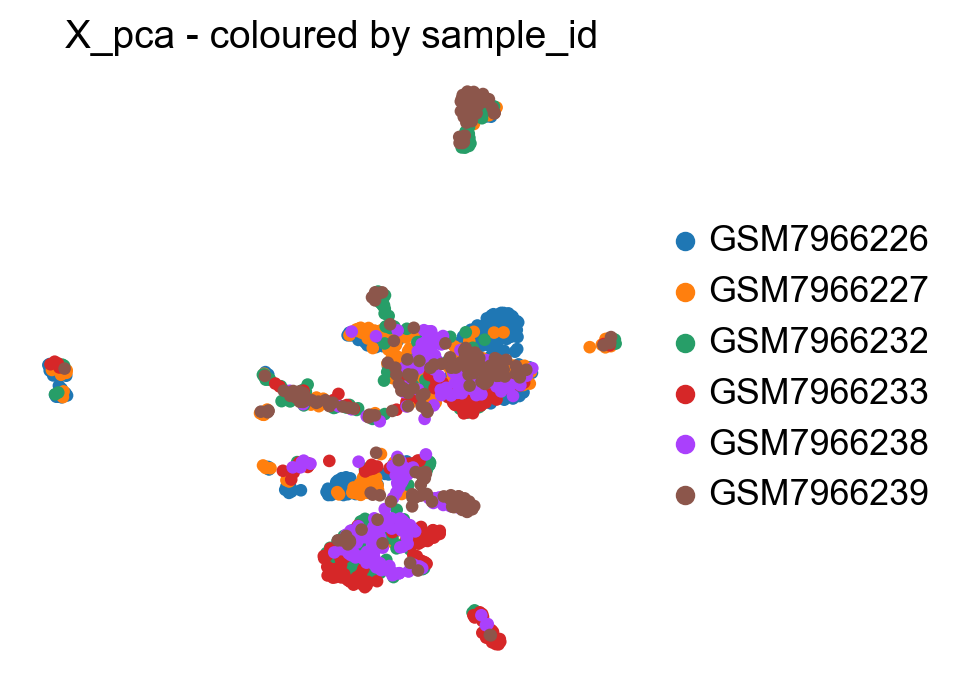

  Saved results/figures/stage4_umap_X_pca_sample_id.png


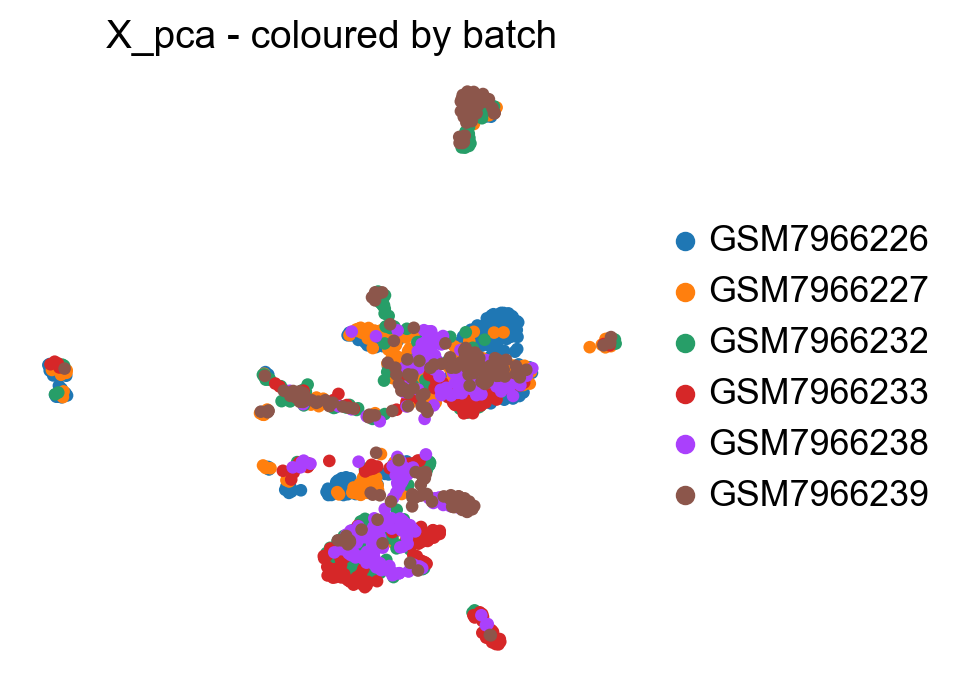

  Saved results/figures/stage4_umap_X_pca_batch.png

--- X_pca_harmony ---
computing neighbors


    finished (0:00:00)


computing UMAP


    finished (0:00:01)


  UMAP saved to obsm['X_umap_pca_harmony']


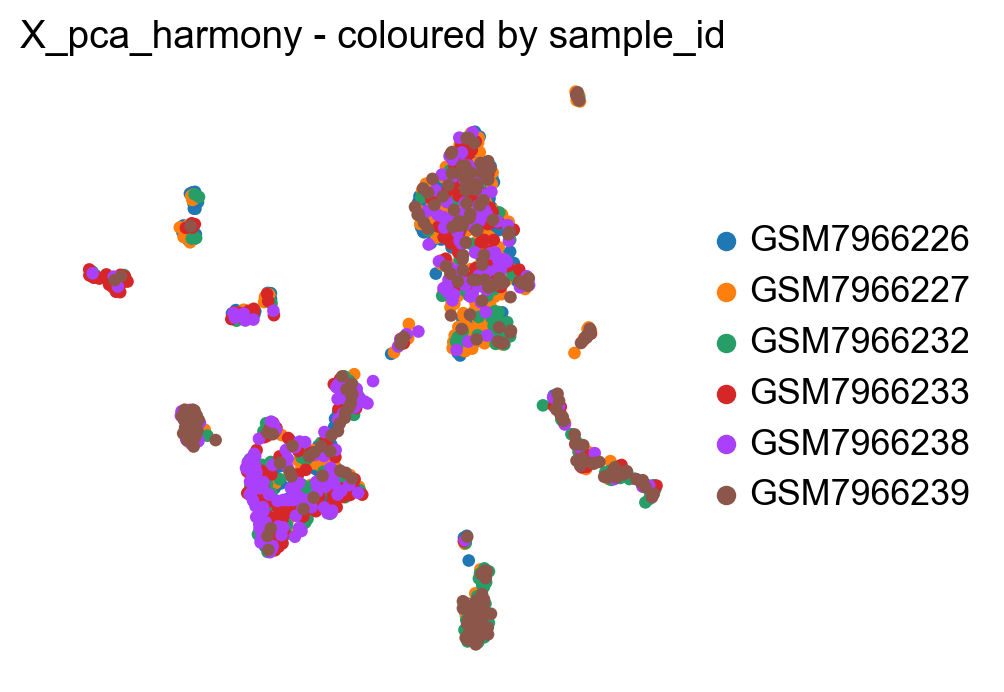

  Saved results/figures/stage4_umap_X_pca_harmony_sample_id.png


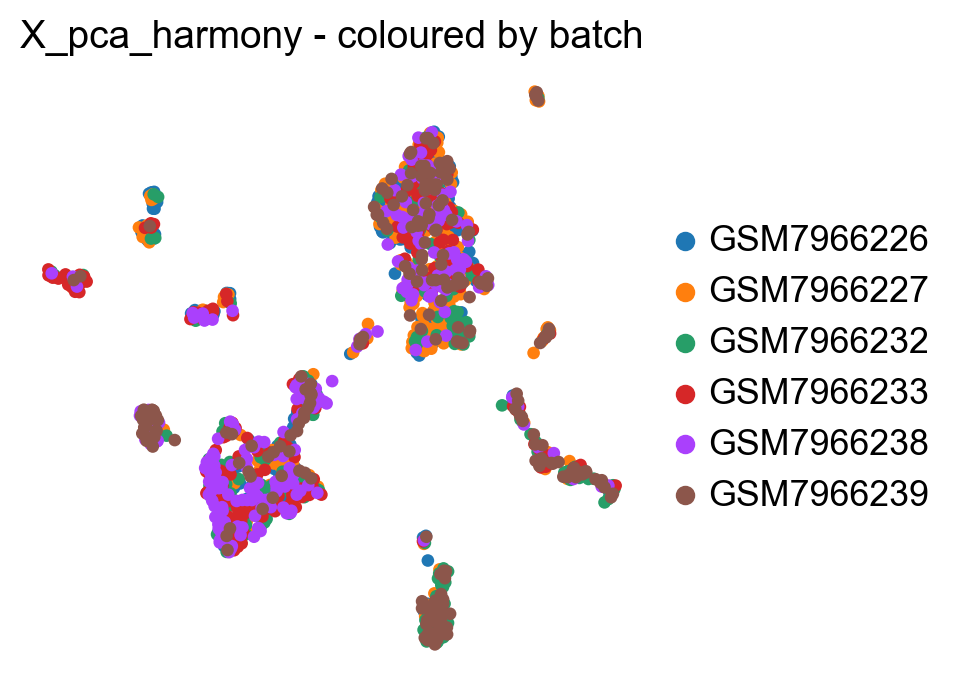

  Saved results/figures/stage4_umap_X_pca_harmony_batch.png

--- X_scVI ---
computing neighbors


    finished (0:00:00)


computing UMAP


    finished (0:00:01)


  UMAP saved to obsm['X_umap_scVI']


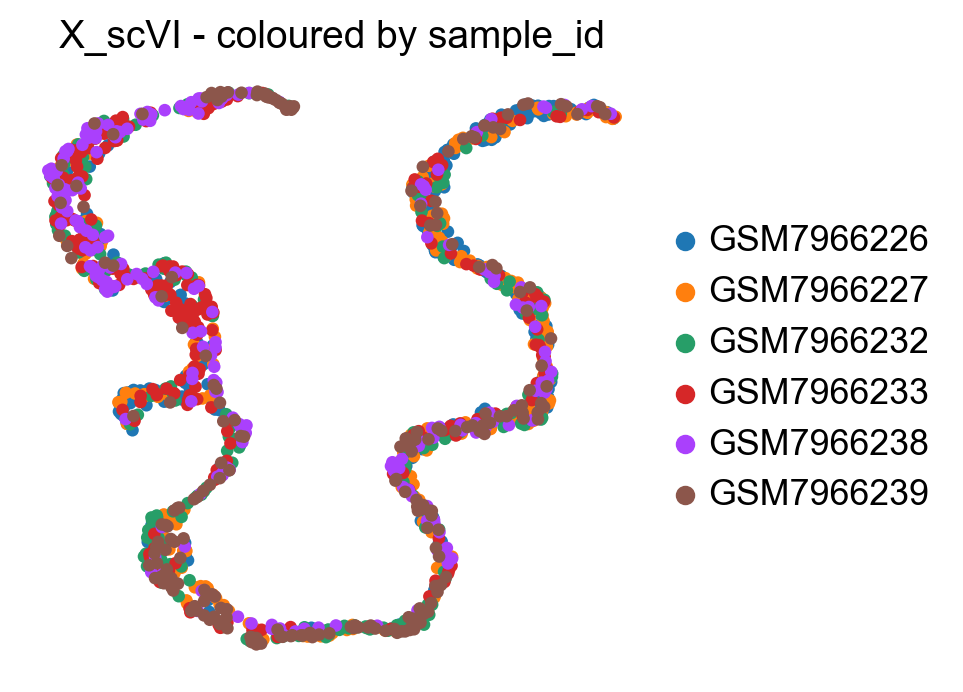

  Saved results/figures/stage4_umap_X_scVI_sample_id.png


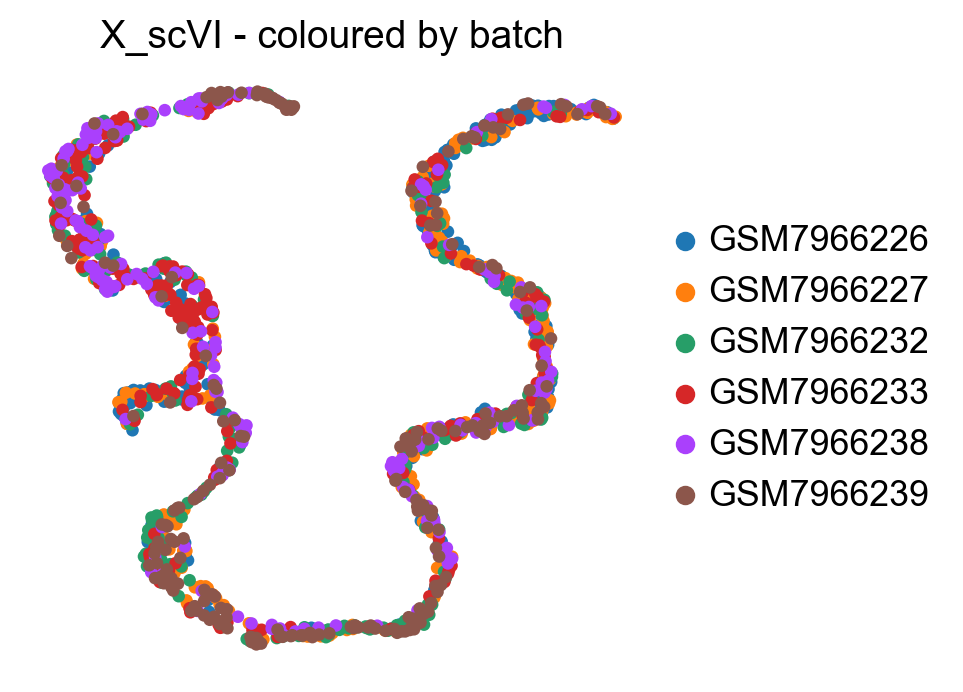

  Saved results/figures/stage4_umap_X_scVI_batch.png


In [9]:
# UMAP per embedding: neighbours -> UMAP -> sc.pl.umap coloured 3 ways.
print("\n===== Visual comparison: UMAP per embedding =====")

# Gather all existing embeddings in obsm.
existing_embeddings = [k for k in adata.obsm.keys()
                       if k.startswith("X_")
                       and adata.obsm[k].shape[1] >= 2]
print(f"Existing embedding keys: {existing_embeddings}")

# Determine available colour columns.
colour_columns = ["sample_id"]
if BATCH_KEY in adata.obs.columns and BATCH_KEY != "sample_id":
    colour_columns.append(BATCH_KEY)
for ct_cand in ["Celltypes_global", "cell_type", "cell_type_original"]:
    if ct_cand in adata.obs.columns:
        colour_columns.append(ct_cand)
        break
print(f"Colour columns: {colour_columns}")

for embed_key in existing_embeddings:
    print(f"\n--- {embed_key} ---")

    # Compute neighbors + UMAP in the embedding space.
    sc.pp.neighbors(adata, use_rep=embed_key, n_pcs=min(N_PCS, adata.obsm[embed_key].shape[1]),
                     random_state=RANDOM_SEED)
    sc.tl.umap(adata, random_state=RANDOM_SEED)

    # Save UMAP coordinates under a dedicated key for traceability.
    umap_key = f"X_umap_{embed_key.lstrip('X_')}"
    adata.obsm[umap_key] = adata.obsm["X_umap"].copy()
    print(f"  UMAP saved to obsm['{umap_key}']")

    # Plot with each colour column.
    for colour in colour_columns:
        if colour in adata.obs.columns:
            fig_name = f"stage4_umap_{embed_key}_{colour}.png"
            sc.pl.umap(
                adata, color=colour,
                title=f"{embed_key} - coloured by {colour}",
                frameon=False,
                save=f"_{embed_key}_{colour}.png",
            )
            # Move from scanpy default figures/ dir to results/figures/.
            src = f"figures/umap_{embed_key}_{colour}.png"
            dst = f"results/figures/{fig_name}"
            if os.path.exists(src):
                os.rename(src, dst)
                print(f"  Saved {dst}")
            plt.close("all")
        else:
            print(f"  (colour '{colour}' not in obs - skipped)")

## Sweep across embeddings with integration_metrics (corroborating)

Quantitative batch-mixing and biology-preservation metrics for each
embedding, computed via `sweep()` with the `integration_metrics` scorer.

Metrics computed (when data permits):
- **silhouette_batch** -- lower = better batch mixing
- **silhouette_celltype** -- higher = better biological signal preservation
- **scib_available** -- 1.0 if `scib-metrics` is installed; 0.0 if not

The sweep report is written to `results/figures/sweep_stage4/sweep_report.md`.
PI inspects this table alongside the UMAP plots to decide which embedding
to promote.

In [10]:
# Sweep: for each existing embedding, compute neighbors+UMAP and score.
print("\n===== Sweep: integration_metrics across embeddings =====")

def neighbors_then_umap(_adata, use_rep):
    sc.pp.neighbors(_adata, use_rep=use_rep, n_pcs=min(N_PCS, _adata.obsm[use_rep].shape[1]),
                     random_state=RANDOM_SEED)
    sc.tl.umap(_adata, random_state=RANDOM_SEED)

# Only sweep over embeddings that exist and have been computed.
use_reps = [k for k in ["X_pca", "X_pca_harmony", "X_scVI", "X_scANVI"]
            if k in adata.obsm]
if not use_reps:
    print("WARNING: no embeddings found in obsm. Sweep skipped.")
else:
    print(f"Sweeping over {len(use_reps)} embeddings: {use_reps}")

    sweep_df = sweep(
        fn=neighbors_then_umap,
        adata=adata,
        candidates={"use_rep": use_reps},
        scorer=integration_metrics,
        output_dir="results/figures/sweep_stage4",
    )

    print("\nIntegration metrics table:")
    try:
        from IPython.display import display as ipy_display
        ipy_display(sweep_df)
    except ImportError:
        print(sweep_df)

    print("\nSweep report written to results/figures/sweep_stage4/sweep_report.md")
    adata.uns["stage4_sweep_v1"] = {
        "embeddings_swept": use_reps,
        "scorer": "integration_metrics",
        "report_dir": "results/figures/sweep_stage4",
        "timestamp": datetime.datetime.now().isoformat(),
    }


===== Sweep: integration_metrics across embeddings =====
Sweeping over 3 embeddings: ['X_pca', 'X_pca_harmony', 'X_scVI']
computing neighbors


    finished (0:00:00)


computing UMAP


    finished (0:00:01)


computing neighbors


...

computing UMAP


    finished (0:00:01)



Integration metrics table:


,use_rep,silhouette_batch,scib_available
0,X_pca,-0.052113,0.0
1,X_pca_harmony,-0.052113,0.0
2,X_scVI,-0.052113,0.0



Sweep report written to results/figures/sweep_stage4/sweep_report.md


## Run metadata -- plain `adata.uns` writes (SPEC convention)

Versioned keys (`harmony_v1`, `scvi_v1`, etc.) record which method ran
with which parameters. PI uses these for traceability and re-runs.

In [11]:
# Record per-method run metadata (versioned keys for re-run coexistence).
print("\n===== Run metadata =====")

if "X_pca" in adata.obsm:
    adata.uns["pca_v1"] = {
        "method": "pca",
        "n_comps": N_PCS,
        "use_hvg": True,
        "svd_solver": "arpack",
        "obsm_key": "X_pca",
        "timestamp": datetime.datetime.now().isoformat(),
    }

if "X_pca_harmony" in adata.obsm:
    adata.uns["harmony_v1"] = {
        "method": "harmony",
        "batch_key": BATCH_KEY,
        "n_pcs": N_PCS,
        "obsm_key": "X_pca_harmony",
        "timestamp": datetime.datetime.now().isoformat(),
    }

if "X_scVI" in adata.obsm:
    adata.uns["scvi_v1"] = {
        "method": "scVI",
        "batch_key": BATCH_KEY,
        "n_latent": SCVI_N_LATENT,
        "n_layers": SCVI_N_LAYERS,
        "max_epochs": SCVI_MAX_EPOCHS,
        "gene_likelihood": "zinb",
        "obsm_key": "X_scVI",
        "timestamp": datetime.datetime.now().isoformat(),
    }

if "X_scANVI" in adata.obsm:
    adata.uns["scanvi_v1"] = {
        "method": "scANVI",
        "batch_key": BATCH_KEY,
        "n_latent": SCVI_N_LATENT,
        "obsm_key": "X_scANVI",
        "timestamp": datetime.datetime.now().isoformat(),
    }

# upstream provenance
adata.uns["upstream"] = [UPSTREAM_PATH]
adata.uns["status"] = "experimental"  # PI changes to "promoted" after review

# Summary of what was run.
active_embeddings = [k for k in adata.obsm.keys()
                     if k.startswith("X_pca") or k.startswith("X_sc")]
print(f"Embeddings produced: {active_embeddings}")
print(f"status: {adata.uns['status']}")
for k in sorted(adata.uns.keys()):
    if k.endswith("_v1"):
        print(f"  {k}: {list(adata.uns[k].keys())}")


===== Run metadata =====
Embeddings produced: ['X_pca', 'X_pca_harmony', 'X_scVI']
status: experimental
  filter_v1: ['cells_in', 'cells_out', 'params', 'timestamp']
  harmony_v1: ['method', 'batch_key', 'n_pcs', 'obsm_key', 'timestamp']
  normalize_v1: ['hvg_flavor', 'log_transformed', 'n_hvg', 'n_top_genes', 'target_sum', 'timestamp']
  pca_v1: ['method', 'n_comps', 'use_hvg', 'svd_solver', 'obsm_key', 'timestamp']
  scvi_v1: ['method', 'batch_key', 'n_latent', 'n_layers', 'max_epochs', 'gene_likelihood', 'obsm_key', 'timestamp']
  stage4_sweep_v1: ['embeddings_swept', 'scorer', 'report_dir', 'timestamp']


## Float32 cast -- Memory Discipline #5

scVI/scANVI outputs are float64 by default. Casting to float32
halves memory for no meaningful precision loss.

In [12]:
# Cast all obsm latent matrices to float32 (Memory Discipline #5).
print("\n===== Float32 cast =====")
for key in list(adata.obsm.keys()):
    if adata.obsm[key].dtype != np.float32:
        adata.obsm[key] = adata.obsm[key].astype(np.float32)
        print(f"  obsm['{key}'] cast to float32")
print("All obsm dtypes:")
for key in adata.obsm:
    print(f"  obsm['{key}']: shape={adata.obsm[key].shape}, dtype={adata.obsm[key].dtype}")


===== Float32 cast =====
  obsm['X_pca_harmony'] cast to float32
All obsm dtypes:
  obsm['X_pca']: shape=(1453, 30), dtype=float32
  obsm['X_pca_harmony']: shape=(1453, 30), dtype=float32
  obsm['X_scVI']: shape=(1453, 10), dtype=float32
  obsm['X_umap']: shape=(1453, 2), dtype=float32
  obsm['X_umap_pca']: shape=(1453, 2), dtype=float32
  obsm['X_umap_pca_harmony']: shape=(1453, 2), dtype=float32
  obsm['X_umap_scVI']: shape=(1453, 2), dtype=float32


In [13]:
# Memory discipline self-check (one assertion before write -- SPEC Memory Discipline).
# Guards the highest-impact memory regression: adata.X becoming dense or losing float32.
import scipy.sparse as sp
import numpy as np
assert sp.issparse(adata.X) and adata.X.dtype == np.float32, (
    f"adata.X invariants violated: sparse={sp.issparse(adata.X)}, dtype={adata.X.dtype}"
)
print("Memory self-check passed: X is sparse CSR float32.")

Memory self-check passed: X is sparse CSR float32.


In [14]:
# Write the stage checkpoint to disk (Memory Discipline #4: lzf compression).
adata.write_h5ad(OUTPUT_PATH, compression="lzf")
print(f"Wrote {OUTPUT_PATH}")

import os
assert os.path.exists(OUTPUT_PATH), f"Output NOT found: {OUTPUT_PATH}"
print(f"Verified: {OUTPUT_PATH} ({os.path.getsize(OUTPUT_PATH):,} bytes)")

Wrote results/nancang_stage4_embedded_v1.h5ad


Verified: results/nancang_stage4_embedded_v1.h5ad (45,638,600 bytes)


In [15]:
# Free memory across stage boundaries (Memory Discipline #3).
# Without this, the Jupyter kernel keeps the previous stage's AnnData
# alive when the next stage is run in the same kernel session.
del adata
import gc
gc.collect()
print("Memory released.")

Memory released.